# Inside Steam - Cleaning & EDA

## 1. Load Data

In [1]:
import pandas as pd
import numpy as np

In [2]:
file_path = "../data/raw/games_march2025_full.csv"

In [3]:
project_columns = [
    "appid",
    "name",
    "release_date",
    "required_age",
    "price",
    "dlc_count",
    "header_image",
    "windows",
    "mac",
    "linux",
    "metacritic_score",
    "achievements",
    "recommendations",
    "supported_languages",
    "full_audio_languages",
    "developers",
    "publishers",
    "categories",
    "genres",
    "user_score",
    "positive",
    "negative",
    "estimated_owners",
    "average_playtime_forever",
    "average_playtime_2weeks",
    "median_playtime_forever",
    "median_playtime_2weeks",
    "discount",
    "peak_ccu",
    "tags",
    "pct_pos_total",
    "num_reviews_total",
    "pct_pos_recent",
    "num_reviews_recent"
]

In [4]:
df = pd.read_csv(
    file_path,
    usecols=project_columns,
    low_memory=False
)

df.shape

(94948, 34)

In [5]:
df.head()

,appid,name,release_date,required_age,price,dlc_count,header_image,windows,mac,linux,...,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
0,730,Counter-Strike 2,2012-08-21,0,0.00,1,https://shared.akamai.steamstatic.com/store_it...,True,False,True,...,879,5174,350,0,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86,8632939,82,96473
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,0,0.00,0,https://shared.akamai.steamstatic.com/store_it...,True,False,False,...,0,0,0,0,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59,2513842,68,16720
2,570,Dota 2,2013-07-09,0,0.00,2,https://shared.akamai.steamstatic.com/store_it...,True,True,True,...,1536,898,892,0,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595,80,29366
3,271590,Grand Theft Auto V Legacy,2015-04-13,17,0.00,0,https://shared.akamai.steamstatic.com/store_it...,True,False,False,...,771,7101,74,0,117698,"{'Open World': 32644, 'Action': 23539, 'Multip...",87,1803832,92,17517
4,488824,Tom Clancy's Rainbow Six® Siege,2015-12-01,17,19.99,9,https://shared.akamai.steamstatic.com/store_it...,True,False,False,...,0,0,0,0,0,"{'FPS': 8082, 'Multiplayer': 6139, 'Tactical':...",84,1168404,76,13017


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 94948 entries, 0 to 94947
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   appid                     94948 non-null  int64  
 1   name                      94946 non-null  str    
 2   release_date              94948 non-null  str    
 3   required_age              94948 non-null  int64  
 4   price                     94948 non-null  float64
 5   dlc_count                 94948 non-null  int64  
 6   header_image              94948 non-null  str    
 7   windows                   94948 non-null  bool   
 8   mac                       94948 non-null  bool   
 9   linux                     94948 non-null  bool   
 10  metacritic_score          94948 non-null  int64  
 11  achievements              94948 non-null  int64  
 12  recommendations           94948 non-null  int64  
 13  supported_languages       94948 non-null  str    
 14  full_audio_langua

In [7]:
df.duplicated(subset="appid").sum()

np.int64(0)

### Loading Strategy

The cleaning workflow uses a selected subset of the raw dataset containing variables relevant to market positioning, reach, engagement, player reception, product characteristics and future dashboard development.

Columns containing support information, URLs, long descriptions and media assets that are not required for the analytical objectives were excluded from the working dataset.

## 2. Cleaning Strategy

The cleaning process will be performed step by step based on the issues identified during the initial data audit.

Main cleaning actions:
- Preserve the original loaded dataset and work on a separate cleaned copy
- Handle sentinel values used to represent unavailable information
- Remove variables with insufficient analytical coverage
- Convert dates and numerical fields to appropriate data types
- Validate impossible or suspicious values
- Transform `estimated_owners` ranges into analysis-ready features
- Parse multi-valued fields such as genres, categories, developers, publishers and tags
- Check duplicates and identifier consistency
- Create derived variables required for the analysis

In [8]:
df_clean = df.copy()

## 3. Missing and Sentinel Values

In [9]:
review_columns = [
    "pct_pos_total",
    "num_reviews_total",
    "pct_pos_recent",
    "num_reviews_recent"
]

df_clean[review_columns] = (
    df_clean[review_columns]
    .replace(-1, np.nan)
)

In [10]:
df_clean[review_columns].min()

pct_pos_total          0.0
num_reviews_total     10.0
pct_pos_recent         0.0
num_reviews_recent    10.0
dtype: float64

In [11]:
df_clean[review_columns].isna().sum()

pct_pos_total         39575
num_reviews_total     39575
pct_pos_recent        87727
num_reviews_recent    87727
dtype: int64

### Review Metrics

The review-related variables used `-1` as a sentinel value for unavailable information. These values were converted to `NaN` so that they are correctly excluded from statistical calculations while preserving valid zero values.

In [12]:
df_clean = df_clean.drop(columns=["user_score"])

### User Score

`user_score` was removed from the analytical dataset because almost all observations contained a value of 0, providing insufficient coverage for meaningful analysis.

In [13]:
df_clean["metacritic_score"] = (
    df_clean["metacritic_score"]
    .replace(0, np.nan)
)

In [14]:
df_clean["metacritic_score"].describe()

count    3576.000000
mean       73.387304
std        10.207259
min        20.000000
25%        68.000000
50%        75.000000
75%        81.000000
max        97.000000
Name: metacritic_score, dtype: float64

### Metacritic Score

A value of `0` was used to represent unavailable Metacritic information and was converted to `NaN`. Among the available Metacritic scores, the observed values range from 20 upward.

Valid scores were retained for secondary critic-versus-player analysis.

## 4. Data Type Corrections

In [15]:
df_clean["release_date"].head(10)

0    2012-08-21
1    2017-12-21
2    2013-07-09
3    2015-04-13
4    2015-12-01
5    2015-12-01
6    2015-12-01
7    2015-12-01
8    2015-12-01
9    2007-10-10
Name: release_date, dtype: str

In [16]:
df_clean["release_date"].dtype

<StringDtype(storage='python', na_value=nan)>

In [17]:
df_clean["release_date"] = pd.to_datetime(
    df_clean["release_date"],
    errors="coerce"
)

In [18]:
df_clean["release_date"].dtype

dtype('<M8[us]')

In [19]:
df_clean["release_date"].isna().sum()

np.int64(0)

In [20]:
df_clean["release_date"].min(), df_clean["release_date"].max()

(Timestamp('1997-06-30 00:00:00'), Timestamp('2025-03-10 00:00:00'))

In [21]:
df_clean["release_year"] = df_clean["release_date"].dt.year

In [22]:
df_clean["release_year"].describe()

count    94948.000000
mean      2020.892731
std          3.074266
min       1997.000000
25%       2019.000000
50%       2022.000000
75%       2024.000000
max       2025.000000
Name: release_year, dtype: float64

In [23]:
df_clean["release_year"] = (
    df_clean["release_date"]
    .dt.year
    .astype("Int64")
)

In [24]:
df_clean["release_year"].dtype

Int64Dtype()

### Release Date

`release_date` was successfully converted from text to a datetime format. No invalid or missing release dates were identified after conversion.

The observed release dates range from June 1997 to March 2025.

A `release_year` feature was created as an integer variable to support temporal analysis of the Steam catalogue.

In [25]:
numeric_check_columns = [
    "required_age",
    "price",
    "dlc_count",
    "achievements",
    "recommendations",
    "positive",
    "negative",
    "discount",
    "peak_ccu"
]

df_clean[numeric_check_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
required_age,94948.0,0.178287,1.701329,-1.0,0.00,0.00,0.00,21.00
price,94948.0,6.911444,13.071148,0.0,0.99,3.99,9.99,999.98
dlc_count,94948.0,0.563203,14.915685,0.0,0.00,0.00,0.00,3427.00
achievements,94948.0,19.543729,159.798834,0.0,0.00,2.00,19.00,9821.00
recommendations,94948.0,1022.211916,22741.508125,0.0,0.00,0.00,0.00,4401572.00
positive,94948.0,1217.904811,30979.736388,0.0,0.00,8.00,51.00,7480813.00
negative,94948.0,202.126459,5955.812787,0.0,0.00,2.00,15.00,1135108.00
discount,94948.0,4.307094,16.111535,0.0,0.00,0.00,0.00,100.00
peak_ccu,94948.0,92.852719,5554.793609,0.0,0.00,0.00,0.00,1212356.00


In [26]:
df_clean["required_age"].value_counts().sort_index()

required_age
-1         1
 0     93891
 1         2
 3         7
 6         4
 7         5
 10       27
 12       21
 13      156
 14        1
 15        3
 16       31
 17      645
 18      152
 20        1
 21        1
Name: count, dtype: int64

In [27]:
df_clean["required_age"] = (
    df_clean["required_age"]
    .replace(-1, np.nan)
)

In [28]:
df_clean["required_age"].min()

np.float64(0.0)

In [29]:
df_clean["required_age"] = df_clean["required_age"].astype("Int64")

In [30]:
df_clean["required_age"].dtype

Int64Dtype()

### Numeric Validation

Numeric variables were reviewed to identify impossible or suspicious values before applying any transformations.

Most extreme values were retained because they remain plausible within the Steam catalogue and are not necessarily data errors.

For `required_age`, the value `-1` was identified as an invalid placeholder and converted to a missing value. Valid values, including `0`, were preserved.

The column was then converted to Pandas nullable integer format (`Int64`) because age is naturally represented as a whole number while still allowing missing values.

## 5. Feature Engineering

### Estimated Owners

In [31]:
df_clean["estimated_owners"].value_counts(dropna=False)

estimated_owners
0 - 20000                59379
0 - 0                    13656
20000 - 50000             9692
50000 - 100000            4558
100000 - 200000           3009
200000 - 500000           2474
500000 - 1000000          1042
1000000 - 2000000          576
2000000 - 5000000          376
5000000 - 10000000         108
10000000 - 20000000         42
20000000 - 50000000         24
50000000 - 100000000        10
100000000 - 200000000        1
200000000 - 500000000        1
Name: count, dtype: int64

In [32]:
owners_ranges = df_clean["estimated_owners"].str.extract(
    r"(?P<owners_lower>\d+)\s*-\s*(?P<owners_upper>\d+)"
)

owners_ranges.head()

,owners_lower,owners_upper
0,100000000,200000000
1,50000000,100000000
2,200000000,500000000
3,50000000,100000000
4,0,20000


In [33]:
df_clean["owners_lower"] = owners_ranges["owners_lower"].astype("Int64")
df_clean["owners_upper"] = owners_ranges["owners_upper"].astype("Int64")

In [34]:
no_owner_estimate = df_clean["estimated_owners"].eq("0 - 0")

df_clean.loc[
    no_owner_estimate,
    ["owners_lower", "owners_upper"]
] = pd.NA

In [35]:
df_clean["estimated_owners_midpoint"] = (
    (df_clean["owners_lower"] + df_clean["owners_upper"]) / 2
).round().astype("Int64")

In [36]:
df_clean[
    [
        "estimated_owners",
        "owners_lower",
        "owners_upper",
        "estimated_owners_midpoint"
    ]
].sample(10)

,estimated_owners,owners_lower,owners_upper,estimated_owners_midpoint
86955,0 - 20000,0,20000,10000
35514,20000 - 50000,20000,50000,35000
74932,0 - 20000,0,20000,10000
42004,0 - 20000,0,20000,10000
13341,50000 - 100000,50000,100000,75000
76468,0 - 20000,0,20000,10000
78164,0 - 20000,0,20000,10000
78549,0 - 20000,0,20000,10000
41346,20000 - 50000,20000,50000,35000
70591,0 - 20000,0,20000,10000


In [37]:
df_clean["estimated_owners_midpoint"].isna().sum()

np.int64(13656)

### Estimated Owners

`estimated_owners` is provided as ownership ranges rather than exact values.

The original categorical range was preserved, while lower and upper bounds were extracted into separate numerical features. An estimated midpoint was also created to support quantitative analysis and modeling.

The `0 - 0` category was treated as unavailable ownership information rather than as confirmed zero ownership and was therefore converted to missing values in the derived numerical features.

The midpoint is an analytical approximation and should not be interpreted as an exact number of owners.

## 6. Multi-Valued Fields


In [38]:
df_clean["genres"].head()

0                           ['Action', 'Free To Play']
1    ['Action', 'Adventure', 'Massively Multiplayer...
2               ['Action', 'Strategy', 'Free To Play']
3                              ['Action', 'Adventure']
4                                           ['Action']
Name: genres, dtype: str

In [39]:
type(df_clean["genres"].dropna().iloc[0])

str

In [40]:
import ast

In [41]:
def parse_list(value):
    if pd.isna(value):
        return []

    try:
        parsed = ast.literal_eval(value)

        if isinstance(parsed, list):
            return parsed

        return []

    except (ValueError, SyntaxError):
        return []

In [42]:
df_clean["genres"] = df_clean["genres"].apply(parse_list)

In [43]:
df_clean["genres"].head()

0                               [Action, Free To Play]
1    [Action, Adventure, Massively Multiplayer, Fre...
2                     [Action, Strategy, Free To Play]
3                                  [Action, Adventure]
4                                             [Action]
Name: genres, dtype: object

In [44]:
type(df_clean["genres"].iloc[0])

list

In [45]:
df_clean[["name", "genres"]].head(10)

,name,genres
0,Counter-Strike 2,"[Action, Free To Play]"
1,PUBG: BATTLEGROUNDS,"[Action, Adventure, Massively Multiplayer, Fre..."
2,Dota 2,"[Action, Strategy, Free To Play]"
3,Grand Theft Auto V Legacy,"[Action, Adventure]"
4,Tom Clancy's Rainbow Six® Siege,[Action]
5,Tom Clancy's Rainbow Six® Siege,[Action]
6,Tom Clancy's Rainbow Six® Siege,[Action]
7,Tom Clancy's Rainbow Six® Siege,[Action]
8,Tom Clancy's Rainbow Six® Siege,[Action]
9,Team Fortress 2,"[Action, Free To Play]"


In [46]:
list_columns = [
    "developers",
    "publishers",
    "categories",
    "supported_languages",
    "full_audio_languages"
]

In [47]:
for col in list_columns:
    df_clean[col] = df_clean[col].apply(parse_list)

In [48]:
for col in ["genres"] + list_columns:
    sample_value = df_clean[col].iloc[0]
    print(col, type(sample_value), sample_value)

genres <class 'list'> ['Action', 'Free To Play']
developers <class 'list'> ['Valve']
publishers <class 'list'> ['Valve']
categories <class 'list'> ['Multi-player', 'Cross-Platform Multiplayer', 'Steam Trading Cards', 'Steam Workshop', 'In-App Purchases', 'Valve Anti-Cheat enabled', 'Stats', 'Remote Play on Phone', 'Remote Play on Tablet', 'Remote Play on TV', 'Steam Timeline']
supported_languages <class 'list'> ['Czech', 'Danish', 'Dutch', 'English', 'Finnish', 'French', 'German', 'Hungarian', 'Italian', 'Japanese', 'Korean', 'Norwegian', 'Polish', 'Portuguese - Portugal', 'Portuguese - Brazil', 'Romanian', 'Russian', 'Simplified Chinese', 'Spanish - Spain', 'Swedish', 'Thai', 'Traditional Chinese', 'Turkish', 'Bulgarian', 'Ukrainian', 'Greek', 'Spanish - Latin America', 'Vietnamese', 'Indonesian']
full_audio_languages <class 'list'> ['English', 'Indonesian']


In [49]:
for col in ["genres"] + list_columns:
    empty_count = df_clean[col].apply(len).eq(0).sum()
    print(f"{col}: {empty_count:,} empty lists")

genres: 5,441 empty lists
developers: 5,451 empty lists
publishers: 5,780 empty lists
categories: 5,907 empty lists
supported_languages: 5,412 empty lists
full_audio_languages: 55,090 empty lists


In [50]:
all_list_columns = [
    "genres",
    "developers",
    "publishers",
    "categories",
    "supported_languages",
    "full_audio_languages"
]

for col in all_list_columns:
    raw_missing = df[col].isna().sum()
    parsed_empty = df_clean[col].apply(len).eq(0).sum()
    non_missing_but_empty = (
        df[col].notna() &
        df_clean[col].apply(len).eq(0)
    ).sum()

    print(
        f"{col}: "
        f"raw missing = {raw_missing:,}, "
        f"parsed empty = {parsed_empty:,}, "
        f"non-missing but parsed empty = {non_missing_but_empty:,}"
    )

genres: raw missing = 0, parsed empty = 5,441, non-missing but parsed empty = 5,441
developers: raw missing = 0, parsed empty = 5,451, non-missing but parsed empty = 5,451
publishers: raw missing = 0, parsed empty = 5,780, non-missing but parsed empty = 5,780
categories: raw missing = 0, parsed empty = 5,907, non-missing but parsed empty = 5,907
supported_languages: raw missing = 0, parsed empty = 5,412, non-missing but parsed empty = 5,412
full_audio_languages: raw missing = 0, parsed empty = 55,090, non-missing but parsed empty = 55,090


In [51]:
empty_genres_mask = df_clean["genres"].apply(len).eq(0)

df.loc[
    empty_genres_mask,
    "genres"
].value_counts(dropna=False).head(10)

genres
[]    5441
Name: count, dtype: int64

In [52]:
empty_audio_mask = df_clean["full_audio_languages"].apply(len).eq(0)

df.loc[
    empty_audio_mask,
    "full_audio_languages"
].value_counts(dropna=False).head(10)

full_audio_languages
[]    55090
Name: count, dtype: int64

### Multi-Valued Fields

Several variables, including genres, developers, publishers, categories and languages, were stored as text representations of Python lists.

These fields were parsed into actual list objects so that individual values can later be separated and analyzed independently while preserving the relationship between each game and its multiple attributes.

Missing information in these fields was encoded in the raw dataset as empty list strings (`[]`) rather than standard null values. After parsing, these observations are represented as empty Python lists.

In [53]:
df_clean["tags"].head()

0    {'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...
1    {'Survival': 14838, 'Shooter': 12727, 'Battle ...
2    {'Free to Play': 59933, 'MOBA': 20158, 'Multip...
3    {'Open World': 32644, 'Action': 23539, 'Multip...
4    {'FPS': 8082, 'Multiplayer': 6139, 'Tactical':...
Name: tags, dtype: str

In [54]:
type(df_clean["tags"].iloc[0])

str

In [55]:
def parse_dict(value):
    if pd.isna(value):
        return {}

    try:
        parsed = ast.literal_eval(value)

        if isinstance(parsed, dict):
            return parsed

        return {}

    except (ValueError, SyntaxError):
        return {}

In [56]:
df_clean["tags"] = df_clean["tags"].apply(parse_dict)

In [57]:
type(df_clean["tags"].iloc[0])

dict

In [58]:
empty_tags = df_clean["tags"].apply(len).eq(0).sum()

print(f"Empty tag dictionaries: {empty_tags:,}")

Empty tag dictionaries: 22,117


In [59]:
empty_tags_mask = df_clean["tags"].apply(len).eq(0)

df.loc[
    empty_tags_mask,
    "tags"
].value_counts(dropna=False).head()

tags
[]    22117
Name: count, dtype: int64

In [60]:
empty_tags_mask = df_clean["tags"].apply(len).eq(0)

df.loc[
    empty_tags_mask,
    "tags"
].value_counts(dropna=False).head(10)

tags
[]    22117
Name: count, dtype: int64

### Tags

The `tags` field contains text representations of dictionaries, where each tag is associated with a numerical weight.

Populated observations were parsed into Python dictionaries. In the raw dataset, games without tag information were represented as empty lists (`[]`) rather than empty dictionaries. These observations were standardized as empty dictionaries (`{}`) during parsing.

A separate `tag_names` feature was created containing only the tag labels, making tag-level analysis easier while preserving the original tag-weight information.

### Pricing Features

In [61]:
df_clean["is_free"] = df_clean["price"].eq(0)

In [62]:
df_clean["is_free"].value_counts()

is_free
False    75528
True     19420
Name: count, dtype: int64

In [63]:
df_clean["price_band"] = pd.cut(
    df_clean["price"],
    bins=[-0.01, 0, 5, 10, 20, 40, np.inf],
    labels=[
        "Free",
        "$0.01-$4.99",
        "$5-$9.99",
        "$10-$19.99",
        "$20-$39.99",
        "$40+"
    ],
    include_lowest=True
)

In [64]:
df_clean["price_band"].value_counts().sort_index()

price_band
Free           19420
$0.01-$4.99    39477
$5-$9.99       19061
$10-$19.99     12743
$20-$39.99      3350
$40+             897
Name: count, dtype: int64

### Pricing Features

The original `price` variable was preserved and two derived features were created for analysis.

- `is_free` identifies titles whose observed price is $0 in the dataset snapshot.
- `price_band` groups titles into broader pricing segments to support market comparisons and dashboard filtering.

These derived variables complement the exact price rather than replacing it.

### Player Reception Features

In [65]:
df_clean["review_count_calc"] = (
    df_clean["positive"] + df_clean["negative"]
)

In [66]:
(df_clean["review_count_calc"] > 0).sum()

np.int64(72648)

In [67]:
review_comparison = df_clean.loc[
    df_clean["num_reviews_total"].notna(),
    [
        "name",
        "positive",
        "negative",
        "review_count_calc",
        "num_reviews_total",
        "pct_pos_total"
    ]
]

review_comparison.head(10)

,name,positive,negative,review_count_calc,num_reviews_total,pct_pos_total
0,Counter-Strike 2,7480813,1135108,8615921,8632939.0,86.0
1,PUBG: BATTLEGROUNDS,1487960,1024436,2512396,2513842.0,59.0
2,Dota 2,1998462,451338,2449800,2452595.0,81.0
3,Grand Theft Auto V Legacy,1719950,250012,1969962,1803832.0,87.0
4,Tom Clancy's Rainbow Six® Siege,312816,64201,377017,1168404.0,84.0
5,Tom Clancy's Rainbow Six® Siege,312397,64151,376548,1168404.0,84.0
6,Tom Clancy's Rainbow Six® Siege,312232,64137,376369,1168404.0,84.0
7,Tom Clancy's Rainbow Six® Siege,312719,64188,376907,1168404.0,84.0
8,Tom Clancy's Rainbow Six® Siege,1152763,218446,1371209,1168020.0,84.0
9,Team Fortress 2,1025633,120619,1146252,1146642.0,89.0


In [68]:
(
    review_comparison["review_count_calc"]
    == review_comparison["num_reviews_total"]
).mean()

np.float64(0.11236523215285428)

In [69]:
review_comparison["count_difference"] = (
    review_comparison["review_count_calc"]
    - review_comparison["num_reviews_total"]
)

review_comparison["relative_difference_pct"] = (
    review_comparison["count_difference"].abs()
    / review_comparison["num_reviews_total"]
    * 100
)

review_comparison["relative_difference_pct"].describe(
    percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]
)

count    55373.000000
mean        55.161558
std        293.019517
min          0.000000
25%          7.500000
50%         25.000000
75%        100.000000
90%        100.000000
95%        110.154507
99%        336.363636
max      46806.250000
Name: relative_difference_pct, dtype: float64

In [70]:
review_comparison["pct_positive_calc"] = (
    review_comparison["positive"]
    / review_comparison["review_count_calc"]
    * 100
)

review_comparison["positivity_difference"] = (
    review_comparison["pct_positive_calc"]
    - review_comparison["pct_pos_total"]
).abs()

review_comparison["positivity_difference"].describe(
    percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]
)

count    44125.000000
mean         2.725001
std          4.350936
min          0.000000
25%          0.455651
50%          1.081633
75%          3.113006
90%          7.141020
95%         10.864306
99%         21.418824
max         91.000000
Name: positivity_difference, dtype: float64

In [71]:
df_clean = df_clean.drop(columns=["review_count_calc"])

### Player Review Metrics

The relationship between the available review variables was examined before selecting the main reception metrics.

`positive + negative` was compared with `num_reviews_total` and was found not to represent an equivalent review count. Only around 11% of comparable observations were exactly equal, and substantial differences were observed across many games.

However, the positivity rate calculated from `positive` and `negative` was generally much closer to the provided `pct_pos_total`.

For consistency, `num_reviews_total` and `pct_pos_total` will therefore be used as the primary review volume and player reception metrics. The `positive` and `negative` fields will be retained but will not be treated as interchangeable with the total review variables.

In [72]:
df_clean["recent_reception_gap"] = (
    df_clean["pct_pos_recent"]
    - df_clean["pct_pos_total"]
)

In [73]:
df_clean["recent_reception_gap"].notna().sum()

np.int64(7153)

In [74]:
df_clean["recent_reception_gap"].describe()

count    7153.000000
mean       -2.326576
std         9.785715
min       -87.000000
25%        -6.000000
50%        -1.000000
75%         3.000000
max        49.000000
Name: recent_reception_gap, dtype: float64

### Recent Reception Gap

A `recent_reception_gap` feature was created as the difference between recent and overall positive review percentages.

- Positive values indicate stronger recent player reception.
- Negative values indicate weaker recent player reception.
- Values close to zero indicate relatively stable reception.

The metric is calculated only when both recent and overall review information are available.

Among games with both overall and recent review data, recent reception is slightly lower on average, with a median gap of -1 percentage point.

### Engagement Metrics

In [76]:
engagement_columns = [
    "average_playtime_forever",
    "median_playtime_forever",
    "average_playtime_2weeks",
    "median_playtime_2weeks",
    "peak_ccu"
]

engagement_summary = pd.DataFrame({
    "zero_count": [
        (df_clean[col] == 0).sum()
        for col in engagement_columns
    ],
    "nonzero_count": [
        (df_clean[col] > 0).sum()
        for col in engagement_columns
    ],
    "nonzero_pct": [
        round((df_clean[col] > 0).mean() * 100, 2)
        for col in engagement_columns
    ]
}, index=engagement_columns)

engagement_summary

,zero_count,nonzero_count,nonzero_pct
average_playtime_forever,86929,8019,8.45
median_playtime_forever,86929,8019,8.45
average_playtime_2weeks,94229,719,0.76
median_playtime_2weeks,94229,719,0.76
peak_ccu,76008,18940,19.95


In [77]:
(
    (df_clean["average_playtime_forever"] > 0)
    ==
    (df_clean["median_playtime_forever"] > 0)
).mean()

np.float64(1.0)

In [78]:
(
    (df_clean["average_playtime_2weeks"] > 0)
    ==
    (df_clean["median_playtime_2weeks"] > 0)
).mean()

np.float64(1.0)

In [79]:
df_clean["has_lifetime_playtime"] = (
    df_clean["average_playtime_forever"] > 0
)

df_clean["has_recent_playtime"] = (
    df_clean["average_playtime_2weeks"] > 0
)

df_clean["has_peak_ccu"] = (
    df_clean["peak_ccu"] > 0
)

In [80]:
df_clean[
    [
        "has_lifetime_playtime",
        "has_recent_playtime",
        "has_peak_ccu"
    ]
].sum()

has_lifetime_playtime     8019
has_recent_playtime        719
has_peak_ccu             18940
dtype: int64

### Engagement Data Availability

Engagement metrics have substantially lower coverage than market and review variables.

- Lifetime playtime is positive for approximately 8.45% of games.
- Two-week playtime is positive for only 0.76% of games.
- Peak CCU is positive for approximately 19.95% of games.

Average and median playtime measures are available for the same games within both lifetime and two-week periods.

Zero values were preserved because they cannot automatically be assumed to represent missing data.

Instead, availability flags were created to identify games with positive engagement measurements. Lifetime playtime and Peak CCU will be analyzed on clearly defined subsets, while two-week playtime will remain a secondary metric due to its very limited coverage.

## 7. Final Cleaning Validation

In [81]:
print(f"Original rows: {len(df):,}")
print(f"Cleaned rows:  {len(df_clean):,}")
print(f"Duplicate appids: {df_clean['appid'].duplicated().sum()}")

Original rows: 94,948
Cleaned rows:  94,948
Duplicate appids: 0


In [82]:
validation_checks = {
    "Negative prices": (df_clean["price"] < 0).sum(),

    "Discount outside 0-100": (
        (df_clean["discount"] < 0) |
        (df_clean["discount"] > 100)
    ).sum(),

    "Negative required ages": (
        df_clean["required_age"] < 0
    ).sum(),

    "Overall review % outside 0-100": (
        (df_clean["pct_pos_total"] < 0) |
        (df_clean["pct_pos_total"] > 100)
    ).sum(),

    "Recent review % outside 0-100": (
        (df_clean["pct_pos_recent"] < 0) |
        (df_clean["pct_pos_recent"] > 100)
    ).sum(),

    "Metacritic outside 0-100": (
        (df_clean["metacritic_score"] < 0) |
        (df_clean["metacritic_score"] > 100)
    ).sum(),

    "Owners lower > owners upper": (
        df_clean["owners_lower"] > df_clean["owners_upper"]
    ).sum()
}

pd.Series(validation_checks)

Negative prices                   0
Discount outside 0-100            0
Negative required ages            0
Overall review % outside 0-100    0
Recent review % outside 0-100     0
Metacritic outside 0-100          0
Owners lower > owners upper       0
dtype: int64

In [84]:
df_clean["tag_names"] = df_clean["tags"].apply(list)

In [85]:
structure_checks = {
    "genres are lists":
        df_clean["genres"].apply(lambda x: isinstance(x, list)).all(),

    "developers are lists":
        df_clean["developers"].apply(lambda x: isinstance(x, list)).all(),

    "publishers are lists":
        df_clean["publishers"].apply(lambda x: isinstance(x, list)).all(),

    "categories are lists":
        df_clean["categories"].apply(lambda x: isinstance(x, list)).all(),

    "tags are dictionaries":
        df_clean["tags"].apply(lambda x: isinstance(x, dict)).all(),

    "tag_names are lists":
        df_clean["tag_names"].apply(lambda x: isinstance(x, list)).all()
}

pd.Series(structure_checks)

genres are lists         True
developers are lists     True
publishers are lists     True
categories are lists     True
tags are dictionaries    True
tag_names are lists      True
dtype: bool

In [86]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 94948 entries, 0 to 94947
Data columns (total 44 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   appid                      94948 non-null  int64         
 1   name                       94946 non-null  str           
 2   release_date               94948 non-null  datetime64[us]
 3   required_age               94947 non-null  Int64         
 4   price                      94948 non-null  float64       
 5   dlc_count                  94948 non-null  int64         
 6   header_image               94948 non-null  str           
 7   windows                    94948 non-null  bool          
 8   mac                        94948 non-null  bool          
 9   linux                      94948 non-null  bool          
 10  metacritic_score           3576 non-null   float64       
 11  achievements               94948 non-null  int64         
 12  recommendations

In [87]:
df_clean.loc[
    df_clean["name"].isna(),
    ["appid", "name", "release_date", "developers", "publishers", "genres"]
]

,appid,name,release_date,developers,publishers,genres
26053,396420,NaN,2016-11-01,[],[],[]
36037,1116910,NaN,2019-09-25,[],[],"[Action, Adventure, Casual, Indie, RPG, Simula..."


In [88]:
# Keep track of names that were missing in the original dataset
df_clean["name_was_missing"] = df_clean["name"].isna()

name_corrections = {
    396420: "The Spookening",
    1116910: "I am the dirt-for art (Drowning in Her Sea)"
}

df_clean["name"] = df_clean["name"].fillna(
    df_clean["appid"].map(name_corrections)
)

In [89]:
df_clean["name"].isna().sum()

np.int64(0)

### Missing Game Names

Two records had missing game names despite having valid Steam App IDs.

The corresponding titles were verified using their App IDs and manually restored:
- App ID 396420: The Spookening
- App ID 1116910: I am the dirt-for art (Drowning in Her Sea)

A flag was retained to identify records whose names were missing in the original dataset.

### Cleaning Validation

The cleaned dataset was validated after preprocessing to ensure that the transformations did not remove observations or introduce inconsistent values.

The number of records was preserved, `appid` remained unique, key numerical variables were checked for impossible ranges, and parsed multi-valued fields were verified to contain the expected Python data structures.

The dataset is now ready for exploratory data analysis.

## 8. Exploratory Data Analysis

### 8.1 Steam Catalogue Evolution

The first analysis examines how the number of Steam titles in the dataset has evolved over time.

In [90]:
games_by_year = (
    df_clean["release_year"]
    .value_counts()
    .sort_index()
)

games_by_year

release_year
1997        2
1999        1
2001        2
2002        1
2003        2
2004        2
2005        5
2006        9
2007        9
2008        7
2009       67
2010      167
2011      215
2012      311
2013      464
2014     1529
2015     2528
2016     4163
2017     5967
2018     7491
2019     6159
2020     8630
2021     8727
2022     9926
2023    14016
2024    20427
2025     4121
Name: count, dtype: Int64

In [91]:
games_by_year_df = (
    games_by_year
    .rename_axis("release_year")
    .reset_index(name="game_count")
)

games_by_year_df.head()

,release_year,game_count
0,1997,2
1,1999,1
2,2001,2
3,2002,1
4,2003,2


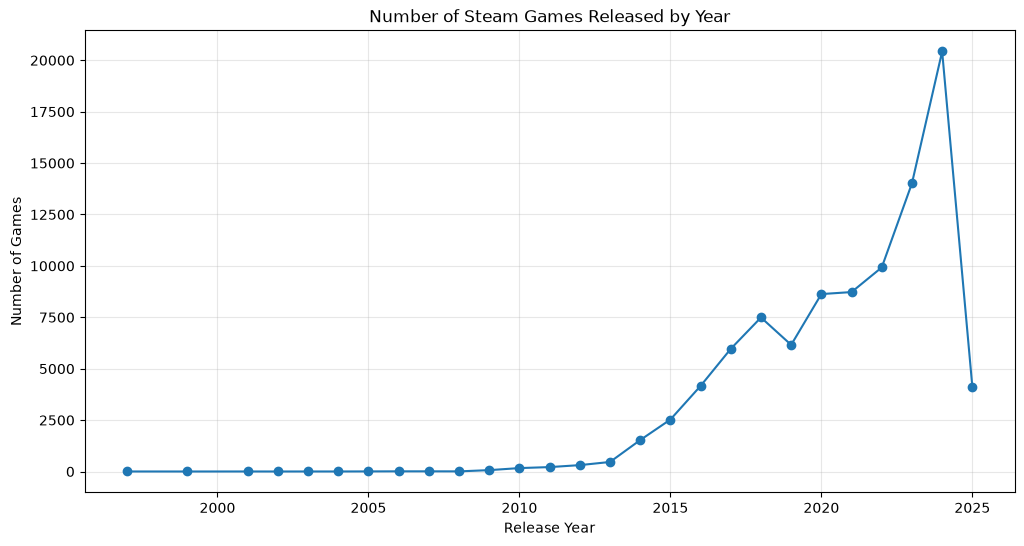

In [92]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    games_by_year_df["release_year"],
    games_by_year_df["game_count"],
    marker="o"
)

plt.title("Number of Steam Games Released by Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Games")
plt.grid(alpha=0.3)

plt.show()

In [93]:
games_by_year_df.tail(10)

,release_year,game_count
17,2016,4163
18,2017,5967
19,2018,7491
20,2019,6159
21,2020,8630
22,2021,8727
23,2022,9926
24,2023,14016
25,2024,20427
26,2025,4121


**Note:** 2025 is only partially represented because the dataset snapshot ends in March 2025. It should therefore not be directly compared with complete previous years.

### Catalogue Evolution - Initial Findings

The number of games released on Steam has increased substantially over time, with particularly strong growth in recent years.

Annual releases increased from 9,926 titles in 2022 to 14,016 in 2023 and 20,427 in 2024, showing a sharp acceleration in catalogue expansion.

The growth has not been completely linear, with some temporary declines or periods of slower growth, such as between 2018 and 2019.

2025 is excluded from direct year-over-year interpretation because the dataset only covers releases through March 10, 2025.

### 8.2 Year-over-Year Growth in Game Releases

In [94]:
games_by_year_df["yoy_growth_pct"] = (
    games_by_year_df["game_count"]
    .pct_change()
    .mul(100)
    .round(2)
)

In [95]:
games_by_year_df.tail(10)

,release_year,game_count,yoy_growth_pct
17,2016,4163,64.68
18,2017,5967,43.33
19,2018,7491,25.54
20,2019,6159,-17.78
21,2020,8630,40.12
22,2021,8727,1.12
23,2022,9926,13.74
24,2023,14016,41.2
25,2024,20427,45.74
26,2025,4121,-79.83


In [96]:
complete_years = games_by_year_df[
    games_by_year_df["release_year"] < 2025
].copy()

In [97]:
complete_years.tail(10)

,release_year,game_count,yoy_growth_pct
16,2015,2528,65.34
17,2016,4163,64.68
18,2017,5967,43.33
19,2018,7491,25.54
20,2019,6159,-17.78
21,2020,8630,40.12
22,2021,8727,1.12
23,2022,9926,13.74
24,2023,14016,41.2
25,2024,20427,45.74


### Year-over-Year Growth - Initial Findings

Annual Steam releases have not grown at a constant rate.

After a decline of approximately 17.8% in 2019, releases rebounded strongly in 2020 with growth of around 40.1%. Growth then remained almost flat in 2021 before accelerating again.

The strongest recent expansion occurred in 2023 and 2024, when the number of released titles increased by approximately 41.2% and 45.7% respectively compared with the previous year.

This suggests a substantial acceleration in catalogue expansion during the most recent complete years.

### 8.3 Genre Distribution

In [98]:
genres_exploded = (
    df_clean[["appid", "name", "genres"]]
    .explode("genres")
)

In [99]:
genre_counts = (
    genres_exploded["genres"]
    .value_counts()
    .reset_index()
)

genre_counts.columns = ["genre", "game_count"]

genre_counts.head(15)

,genre,game_count
0,Indie,63228
1,Casual,38719
2,Action,36894
3,Adventure,35495
4,Simulation,18596
5,Strategy,17380
6,RPG,16350
7,Early Access,9121
8,Free To Play,8873
9,Sports,3948


In [100]:
genre_counts["catalogue_pct"] = (
    genre_counts["game_count"]
    / len(df_clean)
    * 100
).round(2)

genre_counts.head(15)

,genre,game_count,catalogue_pct
0,Indie,63228,66.59
1,Casual,38719,40.78
2,Action,36894,38.86
3,Adventure,35495,37.38
4,Simulation,18596,19.59
5,Strategy,17380,18.30
6,RPG,16350,17.22
7,Early Access,9121,9.61
8,Free To Play,8873,9.35
9,Sports,3948,4.16


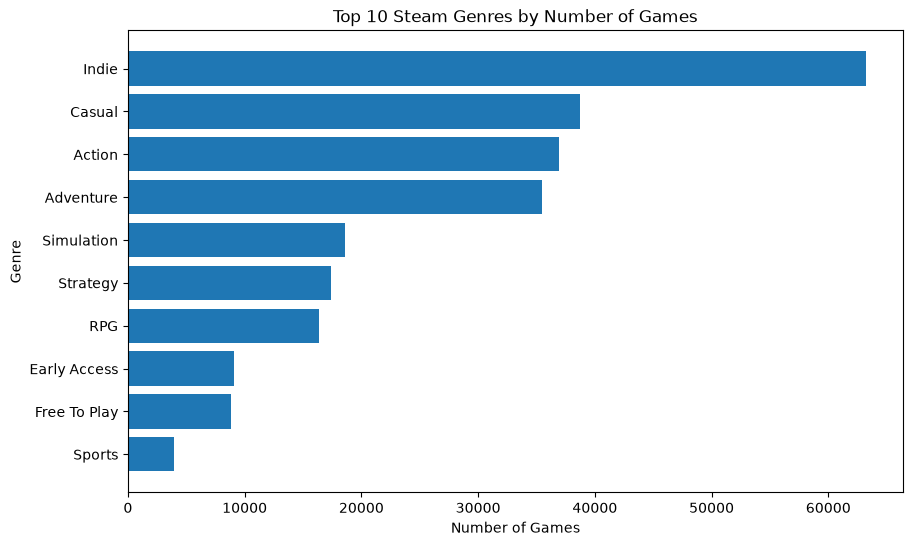

In [101]:
top_genres = genre_counts.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_genres["genre"][::-1],
    top_genres["game_count"][::-1]
)

plt.title("Top 10 Steam Genres by Number of Games")
plt.xlabel("Number of Games")
plt.ylabel("Genre")

plt.show()

### Genre Distribution - Initial Findings

Steam's catalogue is strongly characterized by multi-genre titles, meaning genre percentages overlap and should not be interpreted as mutually exclusive market shares.

`Indie` is by far the most prevalent genre label, appearing in approximately 66.6% of the catalogue. Casual, Action and Adventure are also highly represented, each appearing in more than one-third of all games.

After these four dominant genres, prevalence drops substantially, with Simulation, Strategy and RPG each representing roughly 17-20% of the catalogue.

In [102]:
genre_pricing = (
    df_clean[
        ["appid", "genres", "price", "is_free"]
    ]
    .explode("genres")
    .dropna(subset=["genres"])
    .groupby("genres")
    .agg(
        game_count=("appid", "nunique"),
        median_price=("price", "median"),
        free_share_pct=("is_free", "mean")
    )
    .reset_index()
)

genre_pricing["free_share_pct"] = (
    genre_pricing["free_share_pct"] * 100
).round(2)

In [103]:
top_genre_pricing = (
    genre_pricing
    .sort_values("game_count", ascending=False)
    .head(10)
)

top_genre_pricing

,genres,game_count,median_price,free_share_pct
15,Indie,63228,3.99,14.35
6,Casual,38719,2.99,14.71
2,Action,36894,4.99,15.36
3,Adventure,35495,4.99,13.64
24,Simulation,18596,4.99,13.64
27,Strategy,17380,4.99,15.30
20,RPG,16350,4.99,15.65
9,Early Access,9121,5.99,16.76
12,Free To Play,8873,0.00,99.19
26,Sports,3948,4.99,14.01


### Genre Pricing - Initial Findings

Pricing differences across the most prevalent Steam genres are relatively moderate.

Among the major genres, median prices generally range from $2.99 to $5.99. Casual and Indie titles have slightly lower median prices, while Early Access has the highest median among the top genres.

Outside the `Free To Play` label, the proportion of zero-priced titles is also relatively consistent across major genres, generally ranging from approximately 14% to 17%.

`Free To Play` is a structural exception, with a median price of $0 and almost all titles in that group priced at zero.

In [104]:
paid_genre_pricing = (
    df_clean[df_clean["price"] > 0]
    [["appid", "genres", "price"]]
    .explode("genres")
    .dropna(subset=["genres"])
    .groupby("genres")
    .agg(
        paid_game_count=("appid", "nunique"),
        median_paid_price=("price", "median")
    )
    .reset_index()
)

paid_genre_pricing = (
    paid_genre_pricing
    .sort_values("paid_game_count", ascending=False)
    .head(10)
)

paid_genre_pricing

,genres,paid_game_count,median_paid_price
15,Indie,54157,4.990
6,Casual,33025,4.990
2,Action,31228,4.990
3,Adventure,30655,5.990
24,Simulation,16059,6.990
27,Strategy,14720,5.990
20,RPG,13791,6.990
9,Early Access,7592,7.995
26,Sports,3395,6.990
21,Racing,2863,4.990


### Paid Game Pricing by Genre

After excluding zero-priced titles, differences in median pricing between major genres become more visible.

Indie, Casual, Action and Racing titles have a median paid price of approximately $4.99, while Adventure and Strategy titles are slightly higher at $5.99.

Simulation, RPG and Sports titles show a higher median paid price of $6.99, while Early Access has the highest median among the most prevalent paid-game genres at approximately $8.00.

Overall, genre appears to be associated with some pricing differences, although median prices remain within a relatively narrow range across the major segments.

In [105]:
genre_reach = (
    df_clean[
        ["appid", "genres", "estimated_owners_midpoint"]
    ]
    .explode("genres")
    .dropna(subset=["genres", "estimated_owners_midpoint"])
    .groupby("genres")
    .agg(
        games_with_reach=("appid", "nunique"),
        median_estimated_owners=("estimated_owners_midpoint", "median")
    )
    .reset_index()
)

In [106]:
genre_reach_filtered = (
    genre_reach[
        genre_reach["games_with_reach"] >= 1000
    ]
    .sort_values(
        "median_estimated_owners",
        ascending=False
    )
)

genre_reach_filtered

,genres,games_with_reach,median_estimated_owners
12,Free To Play,3704,35000.0
2,Action,33717,10000.0
3,Adventure,32452,10000.0
6,Casual,34728,10000.0
9,Early Access,8286,10000.0
15,Indie,57917,10000.0
16,Massively Multiplayer,1588,10000.0
20,RPG,14752,10000.0
21,Racing,2970,10000.0
24,Simulation,16832,10000.0


### Genre Reach - Initial Observation

Median estimated ownership is limited by the coarse ownership ranges available in the source data.

For most major genres, the median falls within the `0 - 20,000` owner range, represented by an analytical midpoint of 10,000 owners. As a result, the midpoint median does not provide enough granularity to meaningfully rank these genres by typical reach.

Free To Play stands out with a higher median ownership range of approximately `20,000 - 50,000`.

In [107]:
genre_reach_thresholds = (
    df_clean[
        ["appid", "genres", "owners_lower"]
    ]
    .explode("genres")
    .dropna(subset=["genres", "owners_lower"])
)

genre_reach_thresholds["reach_100k_plus"] = (
    genre_reach_thresholds["owners_lower"] >= 100_000
)

genre_reach_thresholds["reach_1m_plus"] = (
    genre_reach_thresholds["owners_lower"] >= 1_000_000
)

In [108]:
genre_reach_summary = (
    genre_reach_thresholds
    .groupby("genres")
    .agg(
        games_with_reach=("appid", "nunique"),
        share_100k_plus=("reach_100k_plus", "mean"),
        share_1m_plus=("reach_1m_plus", "mean")
    )
    .reset_index()
)

In [109]:
genre_reach_summary["share_100k_plus"] = (
    genre_reach_summary["share_100k_plus"] * 100
).round(2)

genre_reach_summary["share_1m_plus"] = (
    genre_reach_summary["share_1m_plus"] * 100
).round(2)

In [110]:
genre_reach_summary = (
    genre_reach_summary[
        genre_reach_summary["games_with_reach"] >= 1000
    ]
    .sort_values("share_100k_plus", ascending=False)
)

genre_reach_summary

,genres,games_with_reach,share_100k_plus,share_1m_plus
12,Free To Play,3704,28.64,5.45
16,Massively Multiplayer,1588,28.09,7.68
20,RPG,14752,13.12,1.98
27,Strategy,15698,12.15,1.59
2,Action,33717,11.05,2.15
24,Simulation,16832,10.5,1.49
3,Adventure,32452,9.96,1.45
21,Racing,2970,9.06,1.04
15,Indie,57917,8.2,0.84
26,Sports,3585,7.98,1.17


### Genre Reach - Initial Findings

Genre prevalence in the Steam catalogue does not necessarily translate into higher player reach.

Free To Play and Massively Multiplayer titles show the highest proportion of games reaching at least 100,000 estimated owners, at approximately 28% each.

Massively Multiplayer also has the highest share of titles reaching at least 1 million estimated owners, at 7.68%.

By contrast, Indie is the most prevalent genre in the catalogue but only around 8.2% of Indie titles with available reach data fall into ownership ranges of 100,000 or more.

This suggests that catalogue presence and market reach are distinct dimensions of performance.

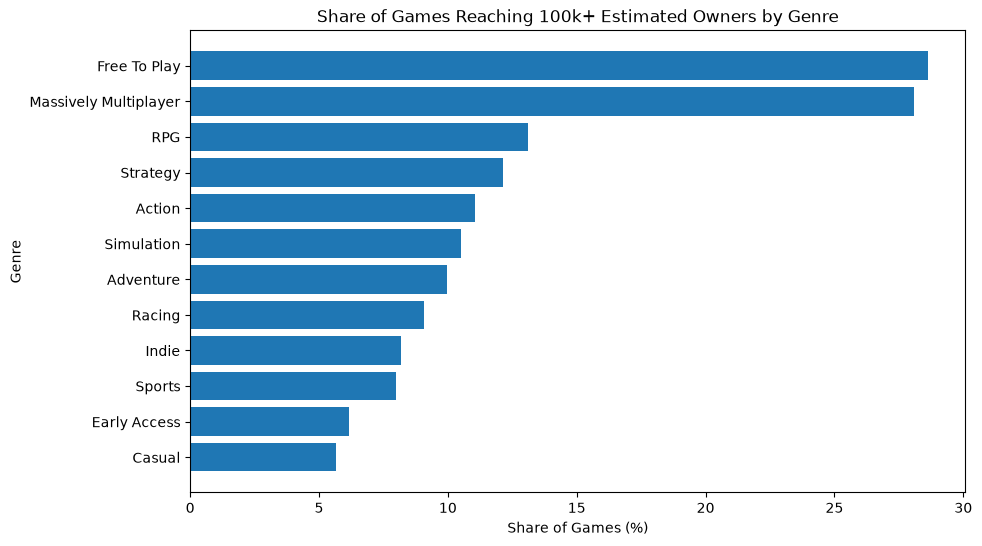

In [111]:
genre_reach_plot = genre_reach_summary.sort_values(
    "share_100k_plus",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    genre_reach_plot["genres"],
    genre_reach_plot["share_100k_plus"]
)

plt.title("Share of Games Reaching 100k+ Estimated Owners by Genre")
plt.xlabel("Share of Games (%)")
plt.ylabel("Genre")

plt.show()

### 8.4 Player Reception by Genre

In [112]:
min_reviews = 50

genre_reception_data = (
    df_clean.loc[
        (df_clean["pct_pos_total"].notna()) &
        (df_clean["num_reviews_total"] >= min_reviews),
        ["appid", "genres", "pct_pos_total", "num_reviews_total"]
    ]
    .explode("genres")
    .dropna(subset=["genres"])
)

In [113]:
genre_reception = (
    genre_reception_data
    .groupby("genres")
    .agg(
        games_with_reviews=("appid", "nunique"),
        median_positive_pct=("pct_pos_total", "median")
    )
    .reset_index()
)

In [114]:
highly_positive_share = (
    genre_reception_data
    .assign(highly_positive=lambda x: x["pct_pos_total"] >= 80)
    .groupby("genres")["highly_positive"]
    .mean()
    .mul(100)
    .round(2)
    .reset_index(name="share_80pct_plus")
)

genre_reception = genre_reception.merge(
    highly_positive_share,
    on="genres"
)

In [115]:
genre_reception_filtered = (
    genre_reception[
        genre_reception["games_with_reviews"] >= 500
    ]
    .sort_values(
        "median_positive_pct",
        ascending=False
    )
)

genre_reception_filtered

,genres,games_with_reviews,median_positive_pct,share_80pct_plus
5,Casual,9911,84.0,60.81
2,Adventure,11996,83.0,58.42
12,Indie,19041,83.0,59.25
1,Action,11282,81.0,53.62
9,Free To Play,4256,80.0,51.74
16,RPG,6478,80.0,51.27
17,Racing,934,80.0,52.68
19,Simulation,7118,79.0,49.73
21,Sports,1170,79.0,48.55
22,Strategy,5972,79.0,48.81


### Player Reception by Genre - Initial Findings

Player reach and player reception show different patterns across Steam genres.

Casual, Adventure and Indie titles have the strongest median player reception among the major genres, with median positive review rates of approximately 83-84%.

Massively Multiplayer presents a notable contrast. Although it previously showed one of the strongest reach profiles, its median positive review rate is only 68%, and just 21.4% of reviewed titles achieve at least 80% positive reviews.

Free To Play combines relatively strong reach with a median player reception of 80%.

Overall, these results suggest that high market reach does not necessarily translate into stronger player satisfaction.

In [116]:
genre_performance = genre_reach_summary.merge(
    genre_reception_filtered[
        [
            "genres",
            "games_with_reviews",
            "median_positive_pct",
            "share_80pct_plus"
        ]
    ],
    on="genres",
    how="inner"
)

genre_performance[
    [
        "genres",
        "share_100k_plus",
        "share_1m_plus",
        "median_positive_pct",
        "share_80pct_plus"
    ]
]

,genres,share_100k_plus,share_1m_plus,median_positive_pct,share_80pct_plus
0,Free To Play,28.64,5.45,80.0,51.74
1,Massively Multiplayer,28.09,7.68,68.0,21.40
2,RPG,13.12,1.98,80.0,51.27
3,Strategy,12.15,1.59,79.0,48.81
4,Action,11.05,2.15,81.0,53.62
5,Simulation,10.5,1.49,79.0,49.73
6,Adventure,9.96,1.45,83.0,58.42
7,Racing,9.06,1.04,80.0,52.68
8,Indie,8.2,0.84,83.0,59.25
9,Sports,7.98,1.17,79.0,48.55


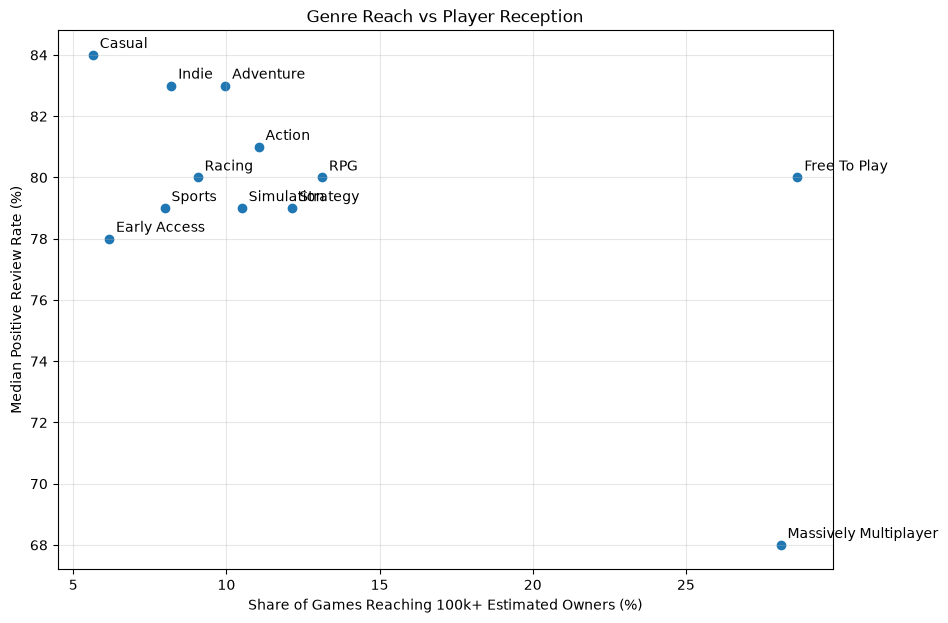

In [117]:
plt.figure(figsize=(10, 7))

plt.scatter(
    genre_performance["share_100k_plus"],
    genre_performance["median_positive_pct"]
)

for _, row in genre_performance.iterrows():
    plt.annotate(
        row["genres"],
        (
            row["share_100k_plus"],
            row["median_positive_pct"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title("Genre Reach vs Player Reception")
plt.xlabel("Share of Games Reaching 100k+ Estimated Owners (%)")
plt.ylabel("Median Positive Review Rate (%)")
plt.grid(alpha=0.3)

plt.show()

### Reach vs Player Reception

The relationship between market reach and player reception varies substantially across genres.

Free To Play and Massively Multiplayer titles have similarly high proportions of games reaching 100,000+ estimated owners, but their player reception differs considerably. Free To Play has a median positive review rate of 80%, compared with only 68% for Massively Multiplayer.

Conversely, Casual, Indie and Adventure titles show comparatively lower reach but stronger median player reception, at approximately 83-84%.

Overall, the analysis suggests that market reach and player satisfaction represent distinct dimensions of game performance rather than moving together consistently.

### 8.5 Pricing vs Market Performance

In [118]:
price_reach_data = df_clean.loc[
    df_clean["owners_lower"].notna(),
    ["appid", "price_band", "owners_lower"]
].copy()

price_reach_data["reach_100k_plus"] = (
    price_reach_data["owners_lower"] >= 100_000
)

price_reach = (
    price_reach_data
    .groupby("price_band", observed=True)
    .agg(
        games_with_reach=("appid", "nunique"),
        share_100k_plus=("reach_100k_plus", "mean")
    )
    .reset_index()
)

price_reach["share_100k_plus"] = (
    price_reach["share_100k_plus"] * 100
).round(2)

price_reach

,price_band,games_with_reach,share_100k_plus
0,Free,6955,19.9
1,$0.01-$4.99,38704,4.67
2,$5-$9.99,18769,6.87
3,$10-$19.99,12683,15.33
4,$20-$39.99,3320,29.82
5,$40+,861,28.92


In [119]:
price_reception = (
    df_clean.loc[
        (df_clean["pct_pos_total"].notna()) &
        (df_clean["num_reviews_total"] >= 50),
        ["appid", "price_band", "pct_pos_total"]
    ]
    .groupby("price_band", observed=True)
    .agg(
        games_with_reviews=("appid", "nunique"),
        median_positive_pct=("pct_pos_total", "median")
    )
    .reset_index()
)

price_reception

,price_band,games_with_reviews,median_positive_pct
0,Free,7411,82.0
1,$0.01-$4.99,7240,82.0
2,$5-$9.99,5543,83.0
3,$10-$19.99,6402,84.0
4,$20-$39.99,2181,82.0
5,$40+,464,80.0


In [120]:
price_performance = price_reach.merge(
    price_reception,
    on="price_band",
    how="inner"
)

price_performance

,price_band,games_with_reach,share_100k_plus,games_with_reviews,median_positive_pct
0,Free,6955,19.9,7411,82.0
1,$0.01-$4.99,38704,4.67,7240,82.0
2,$5-$9.99,18769,6.87,5543,83.0
3,$10-$19.99,12683,15.33,6402,84.0
4,$20-$39.99,3320,29.82,2181,82.0
5,$40+,861,28.92,464,80.0


### Pricing vs Market Performance - Initial Findings

Pricing shows a much stronger relationship with market reach than with player reception.

Among paid titles, the share of games reaching at least 100,000 estimated owners increases substantially across higher price bands, from 4.67% in the $0.01-$4.99 segment to approximately 30% in the $20-$39.99 segment.

Free games are a notable exception, with 19.9% reaching 100,000+ estimated owners despite having no observed price.

Player reception varies much less across price bands. Median positive review rates remain between 80% and 84%, with the highest median reception observed in the $10-$19.99 segment.

Overall, higher price bands are associated with greater reach among paid titles, while player satisfaction appears relatively stable across pricing segments.

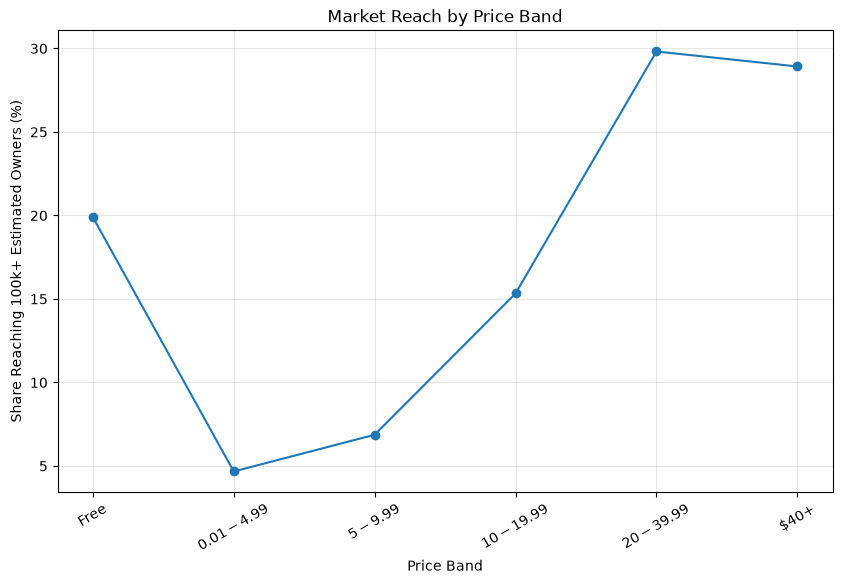

In [121]:
plt.figure(figsize=(10, 6))

plt.plot(
    price_performance["price_band"].astype(str),
    price_performance["share_100k_plus"],
    marker="o"
)

plt.title("Market Reach by Price Band")
plt.xlabel("Price Band")
plt.ylabel("Share Reaching 100k+ Estimated Owners (%)")
plt.xticks(rotation=30)
plt.grid(alpha=0.3)

plt.show()

### Paid Games: Price vs Reach

In [122]:
paid_price_performance = price_performance[
    price_performance["price_band"] != "Free"
].copy()

paid_price_performance

,price_band,games_with_reach,share_100k_plus,games_with_reviews,median_positive_pct
1,$0.01-$4.99,38704,4.67,7240,82.0
2,$5-$9.99,18769,6.87,5543,83.0
3,$10-$19.99,12683,15.33,6402,84.0
4,$20-$39.99,3320,29.82,2181,82.0
5,$40+,861,28.92,464,80.0


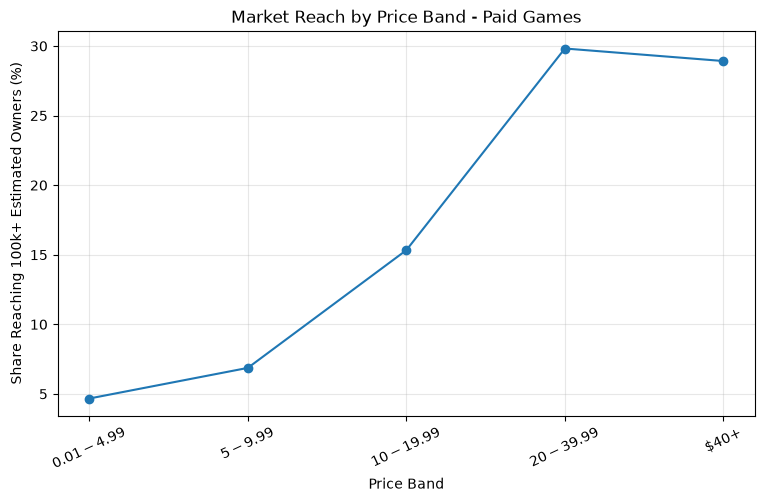

In [123]:
plt.figure(figsize=(9, 5))

plt.plot(
    paid_price_performance["price_band"].astype(str),
    paid_price_performance["share_100k_plus"],
    marker="o"
)

plt.title("Market Reach by Price Band - Paid Games")
plt.xlabel("Price Band")
plt.ylabel("Share Reaching 100k+ Estimated Owners (%)")
plt.xticks(rotation=25)
plt.grid(alpha=0.3)

plt.show()

### Paid Games: Price vs Reach

When free titles are excluded, a clearer relationship appears between observed price and market reach.

Among paid games, the share of titles reaching at least 100,000 estimated owners increases from 4.67% in the lowest price band to approximately 30% in the $20-$39.99 segment.

The pattern then stabilizes, with the $40+ segment showing a similar reach rate of 28.92%.

This indicates an association between higher price positioning and greater market reach among paid titles, but does not establish a causal relationship.

### Paid Games: Price vs Player Reception

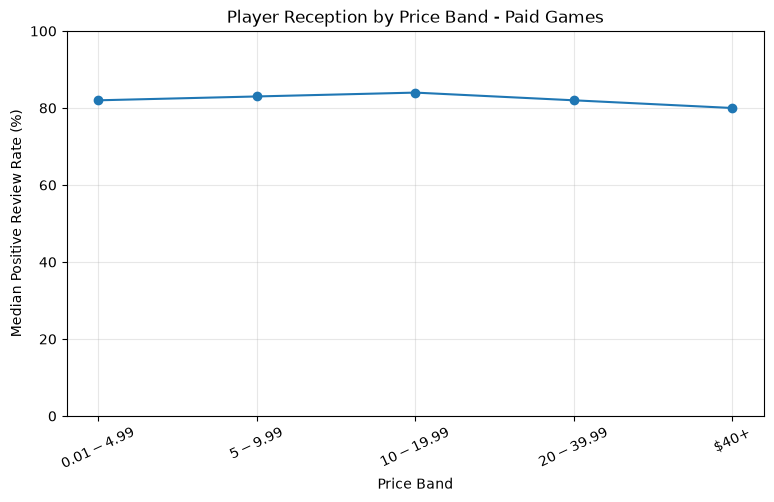

In [125]:
paid_price_reception = price_performance[
    price_performance["price_band"] != "Free"
].copy()

plt.figure(figsize=(9, 5))

plt.plot(
    paid_price_reception["price_band"].astype(str),
    paid_price_reception["median_positive_pct"],
    marker="o"
)

plt.title("Player Reception by Price Band - Paid Games")
plt.xlabel("Price Band")
plt.ylabel("Median Positive Review Rate (%)")
plt.xticks(rotation=25)
plt.grid(alpha=0.3)
plt.ylim(0, 100)
plt.show()

### Paid Games: Price vs Player Reception

Player reception varies much less across paid price bands than market reach.

Median positive review rates remain relatively stable, ranging from 80% to 84% across paid pricing segments. The highest median reception is observed in the $10-$19.99 range, while the $40+ segment has the lowest median at 80%.

This suggests that higher price positioning is associated with greater market reach among paid games, but not with consistently stronger player satisfaction.

### 8.6 Publisher Concentration

In [126]:
publishers_exploded = (
    df_clean[["appid", "publishers"]]
    .explode("publishers")
    .dropna(subset=["publishers"])
)

In [127]:
publisher_counts = (
    publishers_exploded["publishers"]
    .value_counts()
    .reset_index()
)

publisher_counts.columns = ["publisher", "game_count"]

publisher_counts.head(20)

,publisher,game_count
0,Big Fish Games,484
1,8floor,237
2,EroticGamesClub,196
3,Conglomerate 5,187
4,HH-Games,168
5,Laush Studio,160
6,Choice of Games,158
7,Kagura Games,157
8,PlayWay S.A.,156
9,Hede,155


In [129]:
total_publishers = publisher_counts["publisher"].nunique()

print(f"Number of unique publishers: {total_publishers:,}")

Number of unique publishers: 49,860


In [130]:
top_10_share = (
    publisher_counts.head(10)["game_count"].sum()
    / len(df_clean)
    * 100
)

print(f"Top 10 publishers catalogue share: {top_10_share:.2f}%")

Top 10 publishers catalogue share: 2.17%


In [131]:
single_game_publishers = (
    publisher_counts["game_count"] == 1
).sum()

single_game_share = (
    single_game_publishers
    / total_publishers
    * 100
)

print(f"Publishers with only one game: {single_game_publishers:,}")
print(f"Share of publishers with only one game: {single_game_share:.2f}%")


Publishers with only one game: 38,428
Share of publishers with only one game: 77.07%


### Publisher Concentration - Initial Findings

The Steam catalogue is highly fragmented across publishers.

The dataset contains 49,860 unique publisher labels, and approximately 77% of them are associated with only one game.

Even the 10 publishers with the largest catalogues collectively account for only around 2.17% of all games in the dataset. The largest individual publisher appears on fewer than 500 titles.

This indicates a strong long-tail structure, with a very large number of small publishers and relatively limited catalogue concentration among the largest actors.

Publisher names are treated as labels from the source dataset and may not always correspond perfectly to unique corporate entities.

In [132]:
publisher_size = publisher_counts.copy()

publisher_size["publisher_size_tier"] = pd.cut(
    publisher_size["game_count"],
    bins=[0, 1, 5, 20, 100, np.inf],
    labels=[
        "1 game",
        "2-5 games",
        "6-20 games",
        "21-100 games",
        "100+ games"
    ]
)

publisher_size["publisher_size_tier"].value_counts().sort_index()

publisher_size_tier
1 game          38428
2-5 games        9788
6-20 games       1320
21-100 games      291
100+ games         33
Name: count, dtype: int64

### Publisher Size Distribution

Publisher activity is highly concentrated in the smallest catalogue sizes.

Approximately 77% of publisher labels are associated with only one game, while around 97% are associated with five games or fewer.

Only 291 publishers have between 21 and 100 games in the dataset, and just 33 publisher labels are associated with more than 100 titles.

This reinforces the long-tail structure of the Steam publishing landscape, where a very large number of small publishers coexist with a very limited number of high-volume publishers.

In [134]:
publishers_exploded.columns

Index(['appid', 'publishers'], dtype='str')

In [135]:
publishers_exploded = publishers_exploded.rename(
    columns={"publishers": "publisher"}
)

In [136]:
publishers_exploded.columns

Index(['appid', 'publisher'], dtype='str')

In [137]:
publisher_game_data = (
    publishers_exploded
    .merge(
        publisher_size[
            ["publisher", "publisher_size_tier"]
        ],
        on="publisher",
        how="left"
    )
    .merge(
        df_clean[
            ["appid", "owners_lower"]
        ],
        on="appid",
        how="left"
    )
)

In [138]:
publisher_reach_data = publisher_game_data.dropna(
    subset=["owners_lower"]
).copy()

publisher_reach_data["reach_100k_plus"] = (
    publisher_reach_data["owners_lower"] >= 100_000
)

In [139]:
publisher_tier_reach = (
    publisher_reach_data
    .groupby(
        "publisher_size_tier",
        observed=True
    )
    .agg(
        game_publisher_records=("appid", "count"),
        share_100k_plus=("reach_100k_plus", "mean")
    )
    .reset_index()
)

publisher_tier_reach["share_100k_plus"] = (
    publisher_tier_reach["share_100k_plus"] * 100
).round(2)

publisher_tier_reach

,publisher_size_tier,game_publisher_records,share_100k_plus
0,1 game,33817,5.04
1,2-5 games,23134,9.11
2,6-20 games,11617,14.41
3,21-100 games,10993,17.57
4,100+ games,4502,17.64


### Publisher Size vs Market Reach

Market reach increases substantially with publisher catalogue size.

Only 5.04% of game-publisher records associated with single-title publishers reach ownership ranges of 100,000 or more. This proportion rises to 9.11% for publishers with 2-5 games, 14.41% for those with 6-20 games, and approximately 17.6% for publishers with more than 20 titles.

The relationship appears to level off among the largest publishers, with very little difference between the 21-100 and 100+ game tiers.

These results indicate an association between publisher scale and market reach, but do not imply that larger catalogue size directly causes higher reach.

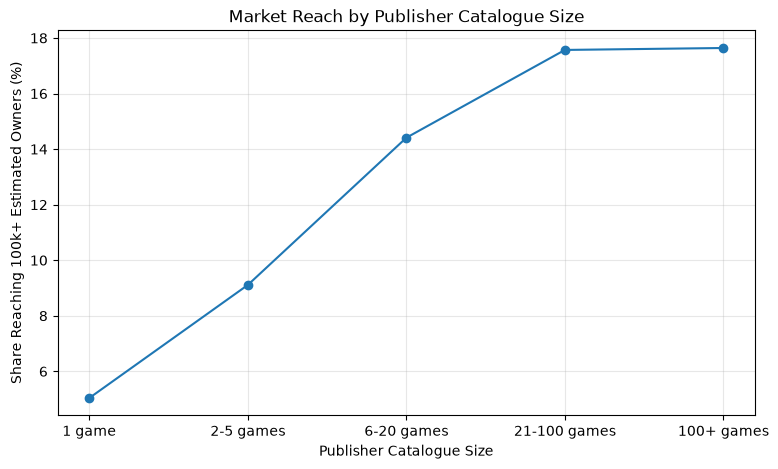

In [140]:
plt.figure(figsize=(9, 5))

plt.plot(
    publisher_tier_reach["publisher_size_tier"].astype(str),
    publisher_tier_reach["share_100k_plus"],
    marker="o"
)

plt.title("Market Reach by Publisher Catalogue Size")
plt.xlabel("Publisher Catalogue Size")
plt.ylabel("Share Reaching 100k+ Estimated Owners (%)")
plt.grid(alpha=0.3)

plt.show()

### Publisher Size vs Player Reception

In [141]:
publisher_reception_data = (
    publisher_game_data
    .merge(
        df_clean[
            ["appid", "pct_pos_total", "num_reviews_total"]
        ],
        on="appid",
        how="left"
    )
)

In [142]:
publisher_reception_data = publisher_reception_data.loc[
    (publisher_reception_data["pct_pos_total"].notna()) &
    (publisher_reception_data["num_reviews_total"] >= 50)
].copy()

In [143]:
publisher_reception_data["highly_positive"] = (
    publisher_reception_data["pct_pos_total"] >= 80
)

In [144]:
publisher_tier_reception = (
    publisher_reception_data
    .groupby(
        "publisher_size_tier",
        observed=True
    )
    .agg(
        game_publisher_records=("appid", "count"),
        median_positive_pct=("pct_pos_total", "median"),
        share_80pct_plus=("highly_positive", "mean")
    )
    .reset_index()
)

publisher_tier_reception["share_80pct_plus"] = (
    publisher_tier_reception["share_80pct_plus"] * 100
).round(2)

publisher_tier_reception

,publisher_size_tier,game_publisher_records,median_positive_pct,share_80pct_plus
0,1 game,7811,83.0,57.34
1,2-5 games,8199,83.0,60.32
2,6-20 games,5718,83.0,58.29
3,21-100 games,5826,81.0,55.29
4,100+ games,2076,80.0,52.22


### Publisher Size vs Player Reception

Unlike market reach, player reception does not improve with publisher catalogue size.

Median positive review rates remain at 83% for publishers with up to 20 games, before declining slightly to 81% for publishers with 21-100 titles and 80% for publishers with more than 100 games.

The share of games achieving at least 80% positive reviews follows a similar pattern, decreasing among the largest publisher tiers.

Combined with the previous reach analysis, this suggests that publisher scale is associated with greater market reach but not with stronger player satisfaction.

### 8.7 Player Engagement

In [145]:
engagement_data = df_clean.loc[
    df_clean["has_lifetime_playtime"],
    [
        "appid",
        "name",
        "average_playtime_forever",
        "median_playtime_forever",
        "estimated_owners_midpoint",
        "pct_pos_total",
        "genres"
    ]
].copy()

engagement_data.shape

(8019, 7)

In [146]:
engagement_data[
    [
        "average_playtime_forever",
        "median_playtime_forever"
    ]
].describe(
    percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]
)

,average_playtime_forever,median_playtime_forever
count,8.019000e+03,8.019000e+03
mean,1.285980e+03,1.283100e+03
std,2.275021e+04,2.941712e+04
min,1.000000e+00,1.000000e+00
25%,6.400000e+01,6.000000e+01
50%,2.180000e+02,2.130000e+02
75%,5.110000e+02,4.430000e+02
90%,1.436200e+03,1.108600e+03
95%,2.669800e+03,1.897500e+03
99%,1.112850e+04,6.659400e+03


In [147]:
engagement_data["average_playtime_hours"] = (
    engagement_data["average_playtime_forever"] / 60
)

engagement_data["median_playtime_hours"] = (
    engagement_data["median_playtime_forever"] / 60
)

In [148]:
engagement_data[
    ["average_playtime_hours", "median_playtime_hours"]
].describe(
    percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]
).round(2)

,average_playtime_hours,median_playtime_hours
count,8019.00,8019.00
mean,21.43,21.39
std,379.17,490.29
min,0.02,0.02
25%,1.07,1.00
50%,3.63,3.55
75%,8.52,7.38
90%,23.94,18.48
95%,44.50,31.62
99%,185.47,110.99


### Lifetime Playtime - Initial Findings

Lifetime playtime is available for 8,019 games and is measured in minutes.

The distribution is strongly right-skewed. The median average lifetime playtime is approximately 3.6 hours, while the mean is much higher at around 21.4 hours.

Most games with available playtime data remain relatively moderate in terms of engagement, while a small number of titles display extremely high playtime values.

Because of this skewed distribution, median playtime will be more informative than the mean for describing typical player engagement.

In [149]:
engagement_data.nlargest(
    10,
    "average_playtime_forever"
)[
    [
        "appid",
        "name",
        "average_playtime_forever",
        "median_playtime_forever"
    ]
]

,appid,name,average_playtime_forever,median_playtime_forever
16196,938270,LoveKami -Healing Harem-,1462997,1462997
9069,707300,Hatsune Miku VR,991837,991837
7528,745960,A Sky Full of Stars 仰望夜空的星辰,727941,1455841
9390,332790,Darkness Assault,533442,1066671
12811,626510,LoveKami -Useless Goddess-,364772,729457
3339,899970,NEKOPARA Extra,146669,95
2259,1146630,Yokai's Secret,82588,80
2000,1406990,NEKOPARA Vol. 4,80800,122
3022,326480,If My Heart Had Wings,79441,744
68534,1173510,XSOverlay,60288,49127


In [150]:
extreme_playtime_games = (
    df_clean
    .loc[
        df_clean["appid"].isin(
            engagement_data.nlargest(
                20,
                "average_playtime_forever"
            )["appid"]
        ),
        [
            "appid",
            "name",
            "estimated_owners",
            "num_reviews_total",
            "peak_ccu",
            "average_playtime_forever",
            "median_playtime_forever"
        ]
    ]
    .sort_values(
        "average_playtime_forever",
        ascending=False
    )
)

extreme_playtime_games

,appid,name,estimated_owners,num_reviews_total,peak_ccu,average_playtime_forever,median_playtime_forever
16196,938270,LoveKami -Healing Harem-,20000 - 50000,184.0,1,1462997,1462997
9069,707300,Hatsune Miku VR,50000 - 100000,592.0,1,991837,991837
7528,745960,A Sky Full of Stars 仰望夜空的星辰,20000 - 50000,845.0,5,727941,1455841
9390,332790,Darkness Assault,200000 - 500000,554.0,0,533442,1066671
12811,626510,LoveKami -Useless Goddess-,20000 - 50000,302.0,0,364772,729457
3339,899970,NEKOPARA Extra,200000 - 500000,3414.0,17,146669,95
2259,1146630,Yokai's Secret,200000 - 500000,6500.0,2,82588,80
2000,1406990,NEKOPARA Vol. 4,200000 - 500000,8017.0,25,80800,122
3022,326480,If My Heart Had Wings,200000 - 500000,3977.0,5,79441,744
68534,1173510,XSOverlay,200000 - 500000,NaN,730,60288,49127


In [151]:
playtime_p99 = engagement_data["median_playtime_hours"].quantile(0.99)

engagement_data["extreme_playtime"] = (
    engagement_data["median_playtime_hours"] > playtime_p99
)

print(f"99th percentile: {playtime_p99:.2f} hours")
print(f"Extreme observations: {engagement_data['extreme_playtime'].sum():,}")

99th percentile: 110.99 hours
Extreme observations: 81


In [152]:
engagement_typical = engagement_data[
    ~engagement_data["extreme_playtime"]
].copy()

### Playtime Outlier Strategy

Inspection of the largest playtime observations showed that extreme values are heterogeneous.

Some very high playtime records are associated with relatively limited review volume and concurrent-player activity, while established high-engagement games also legitimately display large playtime values.

Therefore, extreme playtime observations were not removed from the cleaned dataset.

For robust exploratory analysis, the 99th percentile of median lifetime playtime is used to flag the most extreme 1% of observations. These records remain available in the original engagement dataset but can be excluded from selected visualizations where they would strongly distort the scale.

Median lifetime playtime will be preferred over average lifetime playtime as the main engagement metric because it is less sensitive to extreme player behavior.

In [153]:
df_clean["average_playtime_hours"] = (
    df_clean["average_playtime_forever"] / 60
)

df_clean["median_playtime_hours"] = (
    df_clean["median_playtime_forever"] / 60
)

playtime_p99 = df_clean.loc[
    df_clean["has_lifetime_playtime"],
    "median_playtime_hours"
].quantile(0.99)

df_clean["extreme_playtime"] = (
    df_clean["has_lifetime_playtime"]
    & (df_clean["median_playtime_hours"] > playtime_p99)
)

print(f"99th percentile: {playtime_p99:.2f} hours")
print(f"Extreme observations: {df_clean['extreme_playtime'].sum():,}")

99th percentile: 110.99 hours
Extreme observations: 81


In [154]:
genre_engagement = (
    df_clean.loc[
        df_clean["has_lifetime_playtime"]
        & ~df_clean["extreme_playtime"],
        ["appid", "genres", "median_playtime_hours"]
    ]
    .explode("genres")
    .dropna(subset=["genres"])
    .groupby("genres")
    .agg(
        games_with_playtime=("appid", "nunique"),
        median_playtime_hours=("median_playtime_hours", "median")
    )
    .reset_index()
)

genre_engagement_filtered = (
    genre_engagement[
        genre_engagement["games_with_playtime"] >= 200
    ]
    .sort_values("median_playtime_hours", ascending=False)
)

genre_engagement_filtered.head(10)

,genres,games_with_playtime,median_playtime_hours
17,RPG,1845,4.650000
23,Strategy,1768,4.350000
20,Simulation,1898,4.008333
7,Early Access,512,3.933333
2,Adventure,3359,3.716667
1,Action,3630,3.500000
12,Indie,5234,3.266667
5,Casual,2475,2.850000
18,Racing,291,2.583333
22,Sports,347,2.266667


## 9. EDA Summary

The exploratory analysis reveals several distinct dimensions of performance within the Steam catalogue.

Steam has experienced substantial catalogue expansion, with particularly strong growth in the most recent complete years. Annual releases increased by approximately 41% in 2023 and 46% in 2024.

The catalogue also displays a strong long-tail structure. Indie is the most prevalent genre label, while the publishing landscape is highly fragmented: approximately 77% of publisher labels are associated with only one game and the 10 largest publishers collectively represent only a small share of the catalogue.

Market reach and player reception do not follow the same patterns. Free To Play and Massively Multiplayer games frequently achieve high ownership ranges, while genres such as Casual, Indie and Adventure generally show stronger median player reception. Massively Multiplayer provides a particularly clear example of high reach combined with comparatively weaker player reception.

Pricing is more strongly associated with reach than with satisfaction. Among paid games, higher price bands are increasingly associated with ownership ranges of 100,000 or more, up to the $20-$39.99 segment. Player reception, however, remains relatively stable across price bands, with median positive review rates between approximately 80% and 84%.

Publisher scale shows a similar distinction. Games associated with larger publisher catalogues reach high ownership ranges more frequently, while player reception does not improve with publisher size.

Engagement data is available for a smaller subset of the catalogue and is strongly right-skewed. Median lifetime playtime is therefore preferred to average playtime for describing typical engagement. Extreme observations were retained in the cleaned dataset but flagged so that they can be handled appropriately in later analyses and modeling.

Overall, the EDA suggests that market reach, player engagement and player satisfaction should be treated as complementary rather than interchangeable dimensions of Steam game performance.

### Key Analytical Limitations

- 2025 is only partially represented through March 10 and is not directly comparable with complete years.
- Estimated ownership is provided as ranges rather than exact player counts.
- Playtime, recent reviews, Peak CCU and Metacritic scores are available only for subsets of the catalogue.
- Genres and publishers are multi-valued fields, so their categories are not mutually exclusive.
- Price represents the observed dataset snapshot and should not necessarily be interpreted as a permanent list price.
- Observed relationships are associations and should not be interpreted as causal effects.

## 10. Export Cleaned Dataset

In [155]:
import json
from pathlib import Path

df_export = df_clean.copy()

complex_columns = [
    "supported_languages",
    "full_audio_languages",
    "developers",
    "publishers",
    "categories",
    "genres",
    "tags",
    "tag_names"
]

for col in complex_columns:
    df_export[col] = df_export[col].apply(
        lambda x: json.dumps(x, ensure_ascii=False)
    )

In [156]:
processed_path = Path("../data/processed")
processed_path.mkdir(parents=True, exist_ok=True)

In [157]:
output_file = processed_path / "games_cleaned_march2025.csv"

df_export.to_csv(
    output_file,
    index=False
)

print(output_file)
print(df_export.shape)

../data/processed/games_cleaned_march2025.csv
(94948, 48)


In [158]:
output_file.exists()

True